In [1]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


inspection_id = "0ABP0TFUSH1" #fhr10
angle_profiles = ["0"]
workflow_name = "dent_detection_ae"
num_tracks = 22
run_number = 10
environment = "prod" 

In [2]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"/mnt/f/data-files/{inspection_id}/{workflow_name}"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-ilit0008", f"track_runs/{inspection_id}/{workflow_name}/", results_dir)

In [3]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [4]:
len(data_files), data_files

(807,
 [PosixPath('/mnt/f/data-files/0ABP0TFUSH1/dent_detection_ae/distance_0000000000.0_0000000250.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0ABP0TFUSH1/dent_detection_ae/distance_0000000250.0_0000000500.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0ABP0TFUSH1/dent_detection_ae/distance_0000000500.0_0000000750.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0ABP0TFUSH1/dent_detection_ae/distance_0000000750.0_0000001000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0ABP0TFUSH1/dent_detection_ae/distance_0000001000.0_0000001250.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0ABP0TFUSH1/dent_detection_ae/distance_0000001250.0_0000001500.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0ABP0TFUSH1/dent_detection_ae/distance_0000001500.0_0000001750.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0ABP0TFUSH1

In [42]:
pd.read_csv(data_files[5]).iloc[505]

start                                               1325.6
end                                                 1325.9
prob     [0.0, 0.0, 0.0, 1e-04, 0.0, 0.0, 0.0, 0.0, 0.0...
Name: 505, dtype: object

In [5]:

import ast
# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

## Create a DataFrame for each profile and track and range
def create_df(frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]

    def read_and_validate(path):
        df = pd.read_csv(path)
        if df.empty:
            return df
        df['prob'] = df['prob'].apply(parse_prob)
        df = df[df['prob'].apply(lambda probs: any(p > 0.05 for p in probs))] 
        #add a max_prob column
        df['max_prob'] = df['prob'].apply(lambda probs: max(probs) if probs else 0)
        df['max_prob_track'] = df['prob'].apply(lambda probs: probs.index(max(probs)) if probs else -1)
        return df
    
    dfs = [df for df in (read_and_validate(path) for path in data_files_range) if not df.empty]

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

In [6]:
all_dfs = create_df()
display(all_dfs)

,start,end,prob,max_prob,max_prob_track
49,7.20,7.50,"[0.0, 0.0001, 0.001, 0.115, 0.0015, 0.0017, 0....",0.1150,3
54,7.95,8.25,"[0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.0753,13
56,8.25,8.55,"[0.0, 0.0, 0.0001, 0.0, 0.0001, 0.0, 0.0, 0.0,...",0.9996,20
57,8.40,8.70,"[0.0002, 0.9784, 0.0052, 0.0, 0.0001, 0.0, 0.0...",0.9790,20
61,9.00,9.30,"[0.0005, 0.9555, 0.0393, 0.0, 0.0, 0.0, 0.0, 0...",0.9555,1
...,...,...,...,...,...
810,201621.35,201621.65,"[0.0037, 0.0345, 0.1734, 0.0779, 0.0315, 0.008...",0.9533,9
811,201621.50,201621.80,"[0.0005, 0.0019, 0.0262, 0.0297, 0.0067, 0.003...",0.9515,15
812,201621.65,201621.95,"[0.0, 0.0001, 0.013, 0.0252, 0.0013, 0.0004, 0...",0.9967,20
813,201621.80,201622.10,"[0.0, 0.0001, 0.007, 0.0134, 0.0178, 0.0038, 0...",0.9332,9


In [ ]:
#make a histogram of all max_prob values
plt.style.use('dark_background')
plt.hist(all_dfs[all_dfs['max_prob']>0.995]['max_prob'], bins=50)
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Values')
plt.show() 

In [ ]:
#make the histogram of max_prob_index values
plt.hist(all_dfs[all_dfs['max_prob']>0.99]['max_prob_track'], bins=num_tracks, range=(-0.5, num_tracks-0.5), align='mid')
plt.xlabel('Track Index with Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Track Indices')

In [ ]:
filtered_df = all_dfs[(all_dfs['max_prob']>0.9995) & (~all_dfs['max_prob_track'].isin([9,20]))]
print(f"Filtered DF size: {len(filtered_df)}")
plt.hist(filtered_df['max_prob_track'], bins=num_tracks, range=(-0.5, num_tracks-0.5), align='mid')
plt.xlabel('Track Index with Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Track Indices (Filtered)')
plt.show()

In [7]:
import numpy as np

def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with highest max_prob.
    
    Args:
        df: DataFrame with 'start' and 'max_prob' columns
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start descending
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Group detections within threshold
    starts = df_sorted['start'].values
    probs = df_sorted['max_prob'].values
    
    groups = []
    current_group = [0]
    
    for i in range(1, len(df_sorted)):
        # Check if within threshold of the first item in current group
        if starts[current_group[0]] - starts[i] < distance_threshold:
            current_group.append(i)
        else:
            # Finalize current group, keep highest prob
            groups.append(current_group)
            current_group = [i]
    
    # Don't forget the last group
    groups.append(current_group)
    
    # For each group, keep only the one with max prob
    kept_indices = []
    for group in groups:
        max_prob_idx = group[np.argmax(probs[group])]
        kept_indices.append(max_prob_idx)
    
    return df_sorted.iloc[kept_indices].reset_index(drop=True)

final_df = filter_close_detections(filtered_df)
print(f"Original df: {len(filtered_df)} rows")
print(f"final df: {len(final_df)} rows")

NameError: name 'filtered_df' is not defined

In [ ]:
#save final_df
final_df.to_parquet(f"./insp_{inspection_id}_final_df_ae.parquet", index=False)
display(final_df)

In [ ]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation

root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)

session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="std"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=num_tracks,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.colorbar()
        plt.show()
    return img


Added /home/zmirikha/Github/rnd_q2 to Python path
Loading stub library for: libnppial.so.11
Loading stub library for: libnppig.so.11
Loading stub library for: libnppist.so.11
Loading stub library for: libnppc.so.11
PySettings.cpp(46): ilipy: Build 1.1.0.13962 c753373574 release-ili-1.1 'Wed Mar  4 17:58:39 2026'

PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.

CognitoAuthenticator.cpp(158): Using Cognito Credentials

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

DatabaseWebSocket.cpp(153): WebSocket connection established to https://backend.ili-prod.da

IOStream.flush timed out


ObserverHost.cpp(207): [ObserverHost] Registering with dv-observer at localhost:8000...

ObserverHost.cpp(212): [ObserverHost] Using listening server address localhost:36257

ObserverHost.cpp(250): [ObserverHost] Failed to register with dv-observer, response code: -1



In [ ]:
for i, row in final_df.head(50).iterrows():
    vd = (row['start']+ row['end'])/2
    img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")

    print(vd, row['prob'])

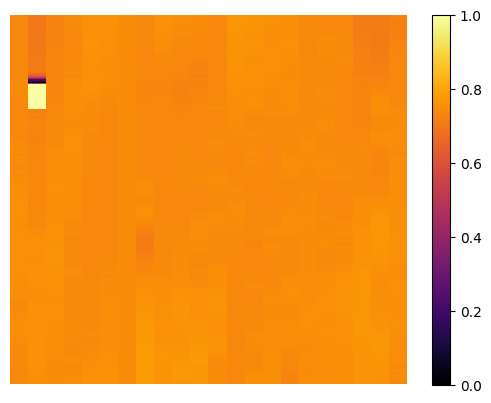

(22, 300)


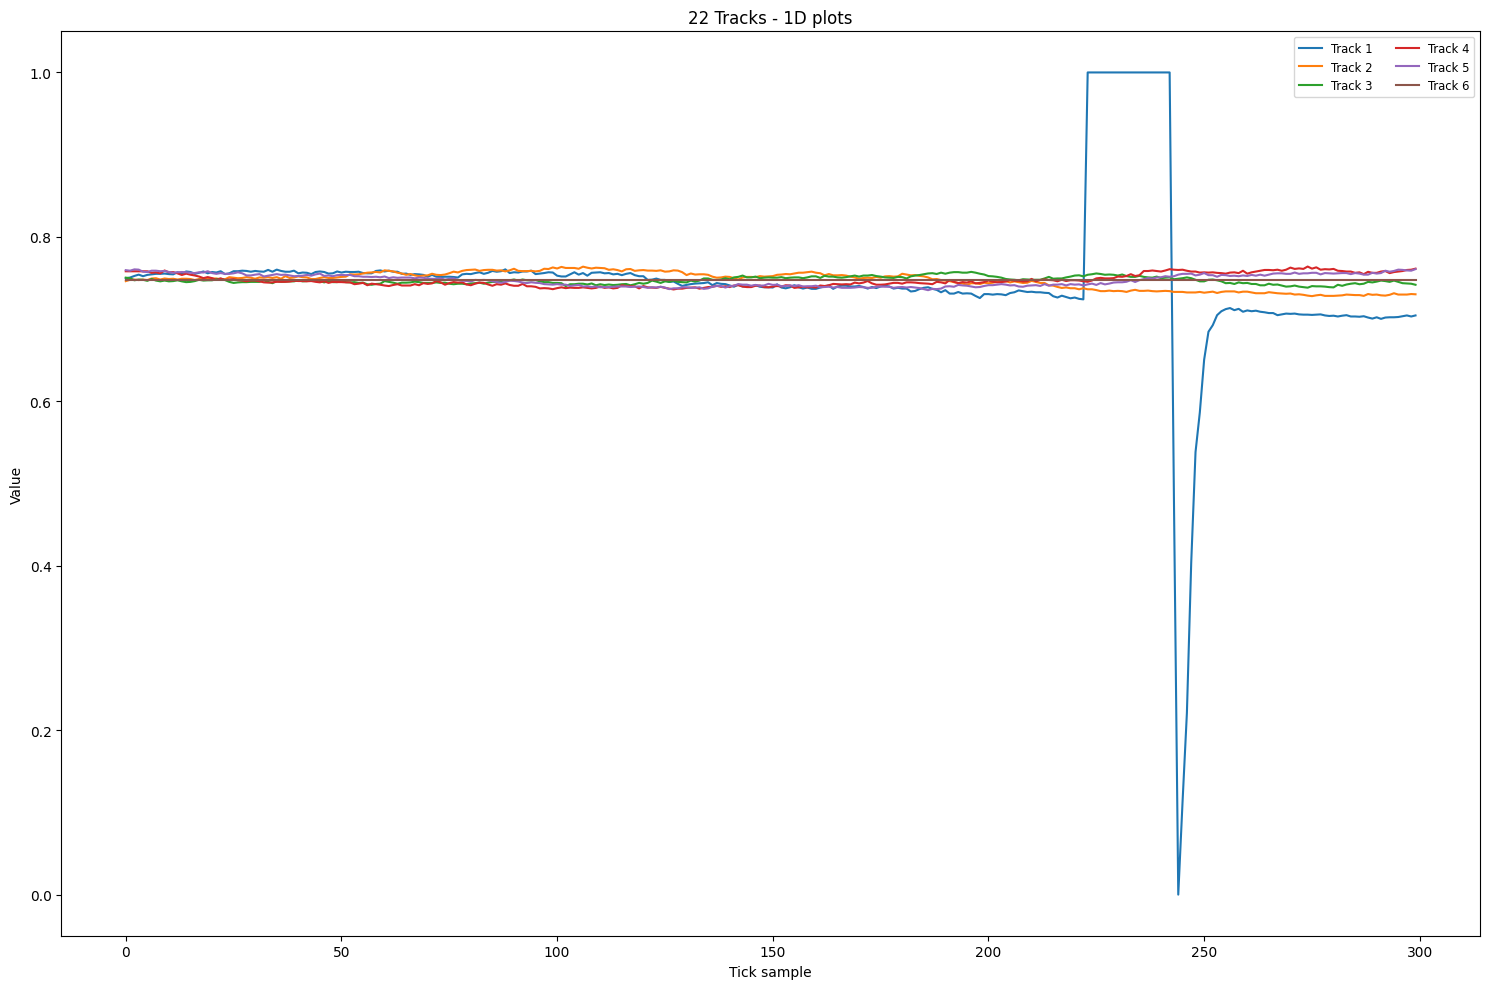

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthentic

In [44]:
img_std = gen_image(1325.911-0.15, session, dist_corr, length=0.3, show_im=True, normalize="std")
print(img_std.shape)

# Plot each row (length-300 array) as a 1D plot, 22 in total
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
for idx in range(1,7):
    plt.plot(img_std[idx], label=f'Track {idx}')
plt.xlabel('Tick sample')
plt.ylabel('Value')
plt.title('22 Tracks - 1D plots')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

## Insert Anomalies

In [ ]:
from ilipy import ClipTypes, Session, TrackIndex, ViewDistance
from ilipy.channeldata import ImageProfile
from ilipy.features import Bookmarks
from ilipyutils.ml_features.base import get_ml_models_info_list, AnomalyStatus
from ilipyutils.ml_features.insert import FeatureInsert, GeometryCubeParameters
from ili_custom_data.load_model import ModelDataLoader
from ilipy.database import DistanceCorrelation

session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)
bookmarks_interface = Bookmarks(connector=session.database_connector)
feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)
latest_model = ModelDataLoader.get_latest_model()

In [ ]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 1000) / 1000
    # The upper bound is just 0.01 more
    upper = round(lower + 0.001, 3)

    return lower, upper

In [ ]:
cube_params = GeometryCubeParameters(
tlbr_cube_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_probe_scan_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_radial_position_mm=(200-(1.9/2), 200+(1.9/2)),
)
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v3"
)
model_info

In [ ]:
print(max_prob)
def f(x):
    return 10*x - 9
f(max_prob)

In [ ]:

# for i, row in final_df.iterrows():
#         print(f"uploading row {i+1} of {len(final_df)}")
#         profile = ImageProfile.ZeroAngle 
#         vd_start, vd_end, _ , max_prob, max_prob_track = row['start'], row['end'], row['prob'], row["max_prob"], row["max_prob_track"]

#         start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(max_prob_track), ViewDistance(vd_start)).value
#         end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(max_prob_track), ViewDistance(vd_end)).value
#         model_instance = latest_model(
#         ml_confidence_score=max_prob,)
#         lower_bound, upper_bound = get_decimal_range(f(max_prob))
#         extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}
#         model_instance = latest_model(
#         ml_confidence_score=max_prob,)


#         anomaly_info = feature_insert.insert_ml_pred(
#         inspection_id=inspection_id,
#         tlbr_track_indices=[max_prob_track,max_prob_track],
#         tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
#         cube_params=cube_params,
#         model_info=model_info,
#         anomaly_status=AnomalyStatus.REVIEW_DETECTION,
#         image_profile=profile,
#         extra_tags=extra_tags,
#         ili_custom_data=model_instance
     #   )


In [ ]:
cube_params

In [ ]:
# from ilipy import OdometerTicks, ViewDistance
# from ilipy.channeldata import ImageProfile
# from ilipy.database import DistanceCorrelation
# from ilipy.features import (
#     AnomalyInfo,
#     AnomalyStatusTypeEnum,
#     CorrosionAnomalyProperties,
#     GeometryBoundingCube,
#     GeometryCubePoint,
#     JointInfo,
#     SurfaceLocationType,
# )
# from ilipyutils.configs import FF_DEFAULTS

In [ ]:
# feat_list = [vd_start, vd_end, max_prob, max_prob_track]
# def create_anomaly(
#     feat_list, inspection_id: str #, required_tag: str | None
# ):  
#     start_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(feat_list[3]), ViewDistance(feat_list[0])).value
#     end_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(feat_list[3]), ViewDistance(feat_list[1])).value
       
#     anomaly = AnomalyInfo()
#     anomaly.feature.inspection_id = inspection_id
#     unique_name = "{}_{}_{}".format(
#         feat_list[3],
#         str(start_odo_ticks),
#         str(end_odo_ticks),
#     )
#     anomaly.feature.name = unique_name
#     # if required_tag:
#     #     anomaly.tags = {required_tag}.union(set(sizing_result["wall_location"]))
#     # else:
#     #     anomaly.tags = set(sizing_result["wall_location"])
#     anomaly.feature.anomaly_identification_type_id = 303
#     anomaly.feature.anomaly_status_type_id = 1

#     # circles = xr.DataArray(
#     #     np.stack(
#     #         [
#     #             np.array(sizing_result["circle_z"]),
#     #             np.array(sizing_result["circle_y"]),
#     #             np.array(sizing_result["circle_r"]),
#     #         ],
#     #         axis=1,
#     #     ),
#     #     coords=LogicalCoordinates.odo_ticks(sizing_result["circle_odo_tick"]),
#     #     dims=[LogicalCoordinates.odo_ticks.dim, "results"],
#     # )
#     # populate_anomaly_with_circles(  # need to make frame start index right
#     #     anomaly=anomaly,
#     #     circles=circles,
#     #     start_frame_idx=sizing_result[
#     #         "circle_start_frame"
#     #     ],  # need original start frame index here
#     # )

#     bm_cube = GeometryBoundingCube(
#         image_profile=ImageProfile.ZeroAngle,
#         top_left=GeometryCubePoint(
#             track_index=feat_list[3],
#             radial_position_mm=199,
#             cube_angle_rad=np.deg2rad(5),
#             probe_scan_angle_rad=FF_DEFAULTS["angle_range_radians"][0],
#             odometer_ticks=OdometerTicks(start_odo_ticks),
#         ),
#         bottom_right=GeometryCubePoint(
#             track_index=feat_list[3],
#             radial_position_mm=201,
#             cube_angle_rad=np.deg2rad(15),
#             probe_scan_angle_rad=FF_DEFAULTS["angle_range_radians"][-1],
#             odometer_ticks=OdometerTicks(end_odo_ticks),
#         ),
#     )


#     anomaly.feature.geometry = bm_cube
#     anomaly.feature.anomaly_status = AnomalyStatusTypeEnum.ReviewDetection

#     return anomaly



In [ ]:
import matplotlib.pyplot as plt

labels = ["Review Detection", "Size Anomaly", "Approved", "False Positive", "Nominal"]
counts = [0, 6740, 214, 6679, 2583]

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Anomaly Status Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on top of each bar
for i, (label, count) in enumerate(zip(labels, counts)):
    plt.text(i, count + 100, str(count), ha='center', va='bottom')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

labels = ["Weld", "Metal Loss", "Lamination", "Dent"]
counts = [1398, 330, 128, 14543]

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Anomaly Type Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on top of each bar
for i, (label, count) in enumerate(zip(labels, counts)):
    plt.text(i, count + 200, str(count), ha='center', va='bottom')

plt.show()

In [ ]:
# feat_list

In [ ]:
# anomaly = create_anomaly(feat_list=feat_list, inspection_id=inspection_id)
# bookmarks_interface.add_anomalies([anomaly])